# Proceso de Markov (cadenas de Markov)

Este notebook ilustra **qué es** un *proceso de Markov* (en particular, una **cadena de Markov** de tiempo discreto) y **cómo funciona** usando un ejemplo sencillo.

## Objetivos de aprendizaje
- Entender la **propiedad de Markov** (*memoria corta*): el futuro depende solo del estado actual.
- Representar un sistema con una **matriz de transición**.
- Simular trayectorias y estimar probabilidades a lo largo del tiempo.
- Calcular y verificar la **distribución estacionaria**.

> Nota: Un **MDP** (Markov Decision Process) es una extensión de esto donde además hay **acciones** y **recompensas**. Aquí nos enfocamos primero en la base: la cadena de Markov.

## 1) ¿Qué es un proceso de Markov?

Un proceso (o cadena) de Markov describe un sistema que **salta entre estados**.

- Llamamos $X_t$ al estado en el tiempo $t$.
- La **propiedad de Markov** se escribe como:

$$\Pr(X_{t+1}=s'\mid X_t=s, X_{t-1},\ldots,X_0)=\Pr(X_{t+1}=s'\mid X_t=s)$$

En palabras: **si conoces el estado actual, la historia completa ya no aporta información adicional** (para predecir el siguiente paso).

## 2) Ejemplo: clima (Sunny / Cloudy / Rainy)

Supón que el clima de mañana depende solo del clima de hoy.
Definimos 3 estados:

- `Sunny` (Soleado)
- `Cloudy` (Nublado)
- `Rainy` (Lluvioso)

Y una **matriz de transición** $P$ donde $P[i,j]$ es la probabilidad de ir del estado *i* hoy al estado *j* mañana.

Por convención, cada **fila** suma 1.

In [11]:
import numpy as np
import pandas as pd

# Estados (en orden)
states = ["Sunny", "Cloudy", "Rainy"]
idx = {s:i for i,s in enumerate(states)}

# Matriz de transición
# Filas: estado actual; Columnas: siguiente estado
P = np.array([
    [0.70, 0.25, 0.05],  # Sunny -> (Sunny, Cloudy, Rainy)
    [0.30, 0.50, 0.20],  # Cloudy -> ...
    [0.20, 0.35, 0.45],  # Rainy  -> ...
])

dfP = pd.DataFrame(P, index=states, columns=states)
dfP

,Sunny,Cloudy,Rainy
Sunny,0.7,0.25,0.05
Cloudy,0.3,0.50,0.20
Rainy,0.2,0.35,0.45


In [12]:
# Verificación rápida: cada fila debe sumar ~1
row_sums = P.sum(axis=1)
pd.DataFrame({"row_sum": row_sums}, index=states)

,row_sum
Sunny,1.0
Cloudy,1.0
Rainy,1.0


### Interpretación rápida
- Si hoy está **Sunny**, mañana sigue **Sunny** con prob. 0.70.
- Si hoy está **Rainy**, mañana pasa a **Cloudy** con prob. 0.35, etc.

Este modelo *no necesita recordar* los últimos 10 días; solo necesita el estado de hoy.

## 3) Simulación de una trayectoria

Simulemos el clima durante varios días a partir de un estado inicial.
La regla es:
1. Observas el estado actual.
2. Tomas la fila correspondiente en $P$.
3. Muestras aleatoriamente el siguiente estado con esas probabilidades.


In [13]:
import random

def sample_next_state(current_state: str, P: np.ndarray, states: list[str]) -> str:
    """Muestrea el siguiente estado dado el estado actual."""
    i = states.index(current_state)
    probs = P[i]
    return random.choices(states, weights=probs, k=1)[0]

def simulate_chain(start_state: str, steps: int, P: np.ndarray, states: list[str]) -> list[str]:
    """Simula una trayectoria de longitud 'steps' (incluye el estado inicial)."""
    trajectory = [start_state]
    current = start_state
    for _ in range(steps):
        current = sample_next_state(current, P, states)
        trajectory.append(current)
    return trajectory

traj = simulate_chain(start_state="Sunny", steps=20, P=P, states=states)
traj

['Sunny',
 'Sunny',
 'Cloudy',
 'Cloudy',
 'Sunny',
 'Sunny',
 'Sunny',
 'Sunny',
 'Sunny',
 'Sunny',
 'Cloudy',
 'Sunny',
 'Sunny',
 'Sunny',
 'Rainy',
 'Cloudy',
 'Cloudy',
 'Rainy',
 'Rainy',
 'Rainy',
 'Rainy']

In [14]:
# Visualización rápida de la trayectoria como tabla
pd.DataFrame({"day": list(range(len(traj))), "state": traj}).head(10)

,day,state
0,0,Sunny
1,1,Sunny
2,2,Cloudy
3,3,Cloudy
4,4,Sunny
5,5,Sunny
6,6,Sunny
7,7,Sunny
8,8,Sunny
9,9,Sunny


## 4) Distribución de estados después de *t* pasos

Si tenemos una distribución inicial $\mu_0$ (por ejemplo, 100% Sunny),
la distribución tras 1 paso es $\mu_1 = \mu_0 P$.

Tras *t* pasos: $\mu_t = \mu_0 P^t$.

Vamos a comparar:
- Predicción por álgebra lineal (potencias de la matriz)
- Estimación por simulación (muchas trayectorias)


In [15]:
def dist_after_t_steps(mu0: np.ndarray, P: np.ndarray, t: int) -> np.ndarray:
    """Calcula mu_t = mu0 P^t."""
    Pt = np.linalg.matrix_power(P, t)
    return mu0 @ Pt

# Distribución inicial: 100% Sunny
mu0 = np.array([1.0, 0.0, 0.0])

t = 10
mu_t = dist_after_t_steps(mu0, P, t)
pd.Series(mu_t, index=states, name=f"mu_{t}")

,mu_10
Sunny,0.471501
Cloudy,0.356248
Rainy,0.172252


In [16]:
def simulate_many(mu0_state: str, steps: int, n_traj: int, P: np.ndarray, states: list[str], seed: int = 7):
    """Simula n_traj trayectorias y estima la distribución en el tiempo 'steps'."""
    random.seed(seed)
    counts = {s: 0 for s in states}
    for _ in range(n_traj):
        traj = simulate_chain(mu0_state, steps, P, states)
        final_state = traj[-1]
        counts[final_state] += 1
    est = np.array([counts[s] for s in states], dtype=float) / n_traj
    return est

n_traj = 20000
mu_est = simulate_many(mu0_state="Sunny", steps=t, n_traj=n_traj, P=P, states=states)

pd.DataFrame({
    "Teórico (mu0 P^t)": mu_t,
    f"Simulado (n={n_traj})": mu_est,
}, index=states)

,Teórico (mu0 P^t),Simulado (n=20000)
Sunny,0.471501,0.47170
Cloudy,0.356248,0.34905
Rainy,0.172252,0.17925


## 5) Distribución estacionaria

Muchas cadenas de Markov *conectadas* y *aperiódicas* tienden a una distribución estable $\pi$ (estacionaria) que cumple:

$$\pi = \pi P$$

Interpretación: si empiezas en $\pi$, después de un paso sigues en $\pi$.

Vamos a calcular $\pi$ y luego a verificarla por simulación larga.

In [17]:
def stationary_distribution(P: np.ndarray) -> np.ndarray:
    """Calcula la distribución estacionaria resolviendo (P^T - I) pi = 0 con sum(pi)=1."""
    n = P.shape[0]
    A = np.vstack([P.T - np.eye(n), np.ones(n)])
    b = np.zeros(n + 1)
    b[-1] = 1
    # mínimos cuadrados (robusto a redondeos)
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    return pi

pi = stationary_distribution(P)
pd.Series(pi, index=states, name="pi (estacionaria)")

,pi (estacionaria)
Sunny,0.471264
Cloudy,0.356322
Rainy,0.172414


In [18]:
# Verificación: pi ≈ pi P
pi_next = pi @ P
pd.DataFrame({"pi": pi, "piP": pi_next, "abs_diff": np.abs(pi - pi_next)}, index=states)

,pi,piP,abs_diff
Sunny,0.471264,0.471264,0.000000e+00
Cloudy,0.356322,0.356322,5.551115e-17
Rainy,0.172414,0.172414,8.326673e-17


In [19]:
# Verificación empírica: simulación muy larga
def long_run_empirical_distribution(start_state: str, steps: int, P: np.ndarray, states: list[str], burn_in: int = 1000, seed: int = 13):
    random.seed(seed)
    traj = simulate_chain(start_state, steps, P, states)
    tail = traj[burn_in:]  # descartamos el inicio (burn-in)
    counts = pd.Series(tail).value_counts().reindex(states, fill_value=0)
    return (counts / counts.sum()).values

emp = long_run_empirical_distribution("Sunny", steps=50000, P=P, states=states)

pd.DataFrame({"pi (teórica)": pi, "empírica (larga)": emp}, index=states)

,pi (teórica),empírica (larga)
Sunny,0.471264,0.469113
Cloudy,0.356322,0.356217
Rainy,0.172414,0.174670


## 6) Visualización simple: evolución de la probabilidad en el tiempo

Vamos a graficar $\mu_t$ para varios valores de *t* partiendo de un estado inicial 100% Sunny.

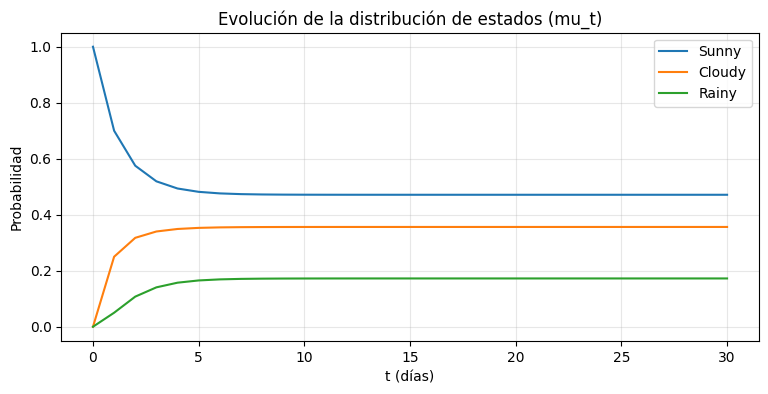

In [20]:
import matplotlib.pyplot as plt

T = 30
mus = []
for t in range(T+1):
    mus.append(dist_after_t_steps(mu0, P, t))
mus = np.array(mus)  # (T+1, n_states)

plt.figure(figsize=(9, 4))
for i, s in enumerate(states):
    plt.plot(range(T+1), mus[:, i], label=s)

plt.title("Evolución de la distribución de estados (mu_t)")
plt.xlabel("t (días)")
plt.ylabel("Probabilidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()